In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

In [2]:
DB_USER = "your username"
DB_PASSWORD = "your password"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "e-commerce_shipping_db"
connection_string = f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
try:
    engine = create_engine(connection_string)
    with engine.connect():
        print("Connected to PostgreSQL successfully.")
except Exception as e:
    print("Connection failed:", e)

Connected to PostgreSQL successfully.


In [3]:
query_all = "SELECT * FROM shipping_data;"
df = pd.read_sql_query(query_all, engine)
print("Shape:", df.shape)
df.info()

Shape: (10999, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   10999 non-null  int64 
 1   warehouse_block      10999 non-null  object
 2   mode_of_shipment     10999 non-null  object
 3   customer_care_calls  10999 non-null  int64 
 4   customer_rating      10999 non-null  int64 
 5   cost_of_the_product  10999 non-null  int64 
 6   prior_purchases      10999 non-null  int64 
 7   product_importance   10999 non-null  object
 8   gender               10999 non-null  object
 9   discount_offered     10999 non-null  int64 
 10  weight_in_gms        10999 non-null  int64 
 11  reached_on_time_y_n  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [4]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df.describe().T

Missing values:
 id                     0
warehouse_block        0
mode_of_shipment       0
customer_care_calls    0
customer_rating        0
cost_of_the_product    0
prior_purchases        0
product_importance     0
gender                 0
discount_offered       0
weight_in_gms          0
reached_on_time_y_n    0
dtype: int64

Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
id,10999.0,5500.000000,3175.282140,1.0,2750.5,5500.0,8249.5,10999.0
customer_care_calls,10999.0,4.054459,1.141490,2.0,3.0,4.0,5.0,7.0
customer_rating,10999.0,2.990545,1.413603,1.0,2.0,3.0,4.0,5.0
cost_of_the_product,10999.0,210.196836,48.063272,96.0,169.0,214.0,251.0,310.0
prior_purchases,10999.0,3.567597,1.522860,2.0,3.0,3.0,4.0,10.0
discount_offered,10999.0,13.373216,16.205527,1.0,4.0,7.0,10.0,65.0
weight_in_gms,10999.0,3634.016729,1635.377251,1001.0,1839.5,4149.0,5050.0,7846.0
reached_on_time_y_n,10999.0,0.596691,0.490584,0.0,0.0,1.0,1.0,1.0


In [5]:
conditions = [
    df["discount_offered"] < 10,
    df["discount_offered"].between(10, 20),
]
choices = ["Low Discount", "Medium Discount"]
df["discount_group"] = np.select(conditions, choices, default="High Discount")

cost_percentiles = np.percentile(df["cost_of_the_product"], [25, 50, 75, 90])
print("Cost percentiles (25/50/75/90):", cost_percentiles)
df["discount_group"].value_counts()

Cost percentiles (25/50/75/90): [169.  214.  251.  269.2]


discount_group
Low Discount       7492
High Discount      2151
Medium Discount    1356
Name: count, dtype: int64

In [6]:
def annotated_barplot(ax, x, y, fmt="{:.1f}", color=None):
    bars = ax.bar(x, y, color=color)
    for b in bars:
        h = b.get_height()
        ax.annotate(fmt.format(h), (b.get_x() + b.get_width() / 2, h),
                    ha="center", va="bottom", fontsize=9)
    return bars

In [7]:
# Warehouse performance and satisfaction rank
q_warehouse = """
SELECT
    warehouse_block,
    COUNT(*) AS total_orders,
    ROUND(AVG(cost_of_the_product), 2) AS avg_product_cost,
    ROUND(AVG(discount_offered), 2) AS avg_discount,
    ROUND(AVG(customer_rating), 2) AS avg_rating,
    SUM(CASE WHEN reached_on_time_y_n = 1 THEN 1 ELSE 0 END) AS late_orders,
    ROUND(SUM(CASE WHEN reached_on_time_y_n = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS late_percentage
FROM shipping_data
GROUP BY warehouse_block
ORDER BY late_percentage DESC;
"""
q_satisfaction_rank = """
SELECT
    warehouse_block,
    ROUND(AVG(customer_rating), 2) AS avg_rating,
    DENSE_RANK() OVER (ORDER BY AVG(customer_rating) DESC) AS satisfaction_rank
FROM shipping_data
GROUP BY warehouse_block;
"""
df_warehouse = pd.read_sql_query(q_warehouse, engine)
df_satisfaction = pd.read_sql_query(q_satisfaction_rank, engine)
warehouse_summary = df_warehouse.merge(df_satisfaction[["warehouse_block", "satisfaction_rank"]],
                                        on="warehouse_block")
warehouse_summary = warehouse_summary.sort_values("late_percentage", ascending=False)
warehouse_summary

,warehouse_block,total_orders,avg_product_cost,avg_discount,avg_rating,late_orders,late_percentage,satisfaction_rank
0,B,1833,212.16,13.19,2.98,1104,60.23,4
1,F,3666,209.08,13.67,3.00,2194,59.85,2
2,D,1834,210.91,13.09,3.02,1096,59.76,1
3,C,1833,211.19,13.40,2.99,1094,59.68,3
4,A,1833,208.77,13.22,2.96,1075,58.65,5


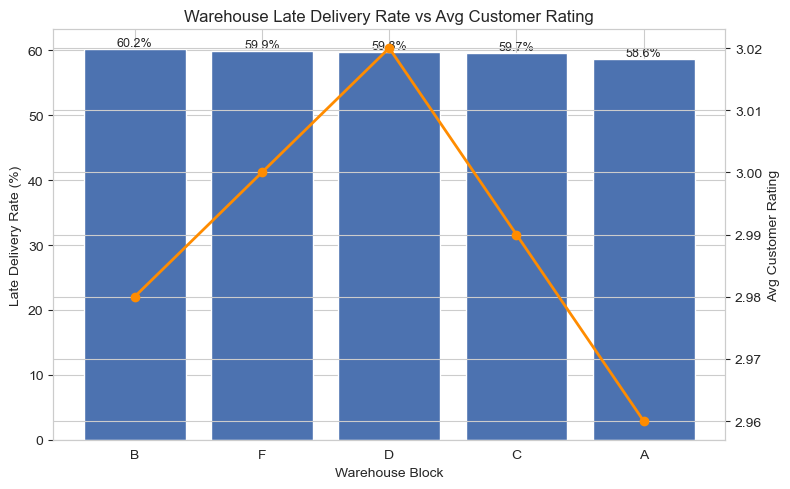

In [8]:
 #Warehouse chart
fig, ax1 = plt.subplots(figsize=(8, 5))
annotated_barplot(ax1, warehouse_summary["warehouse_block"], warehouse_summary["late_percentage"],
                   fmt="{:.1f}%", color="#4C72B0")
ax1.set_ylabel("Late Delivery Rate (%)")
ax1.set_xlabel("Warehouse Block")

ax2 = ax1.twinx()
ax2.plot(warehouse_summary["warehouse_block"], warehouse_summary["avg_rating"],
          color="darkorange", marker="o", linewidth=2)
ax2.set_ylabel("Avg Customer Rating")
ax1.set_title("Warehouse Late Delivery Rate vs Avg Customer Rating")
plt.tight_layout()
plt.savefig("warehouse_performance.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
# Customer segmentation
q_segment = """
SELECT
    CASE
        WHEN prior_purchases >= 8 THEN 'Loyal'
        WHEN prior_purchases BETWEEN 4 AND 7 THEN 'Regular'
        ELSE 'New'
    END AS customer_segment,
    COUNT(*) AS customers,
    ROUND(AVG(customer_rating), 2) AS avg_rating,
    ROUND(AVG(cost_of_the_product), 2) AS avg_spending
FROM shipping_data
GROUP BY customer_segment;
"""
df_segment = pd.read_sql_query(q_segment, engine).sort_values("customers", ascending=False)
df_segment


,customer_segment,customers,avg_rating,avg_spending
1,New,6554,2.98,200.63
0,Regular,4139,2.99,226.01
2,Loyal,306,3.13,201.23


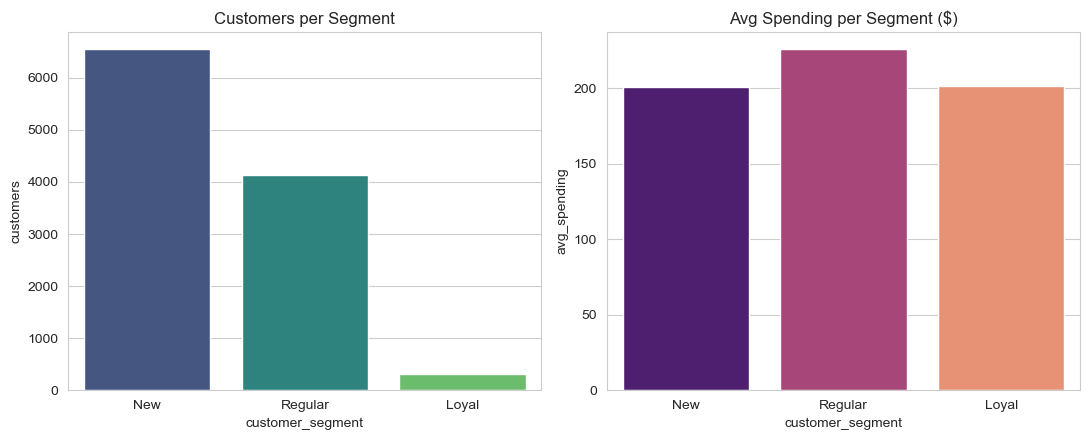

In [10]:
# Segmentation chart
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.barplot(data=df_segment, x="customer_segment", y="customers",
            hue="customer_segment", legend=False, palette="viridis", ax=axes[0])
axes[0].set_title("Customers per Segment")
sns.barplot(data=df_segment, x="customer_segment", y="avg_spending",
            hue="customer_segment", legend=False, palette="magma", ax=axes[1])
axes[1].set_title("Avg Spending per Segment ($)")
plt.tight_layout()
plt.show()

In [11]:
# Discount effect
q_discount = """
SELECT
    CASE
        WHEN discount_offered < 10 THEN 'Low Discount'
        WHEN discount_offered BETWEEN 10 AND 20 THEN 'Medium Discount'
        ELSE 'High Discount'
    END AS discount_group,
    COUNT(*) AS total_orders,
    SUM(CASE WHEN reached_on_time_y_n = 1 THEN 1 ELSE 0 END) AS late_orders,
    ROUND(AVG(customer_rating), 2) AS avg_rating
FROM shipping_data
GROUP BY discount_group;
"""
df_discount = pd.read_sql_query(q_discount, engine)
df_discount["late_pct"] = (df_discount["late_orders"] / df_discount["total_orders"] * 100).round(2)
order = ["Low Discount", "Medium Discount", "High Discount"]
df_discount["discount_group"] = pd.Categorical(df_discount["discount_group"], categories=order, ordered=True)
df_discount = df_discount.sort_values("discount_group")
df_discount

,discount_group,total_orders,late_orders,avg_rating,late_pct
1,Low Discount,7492,3515,2.99,46.92
2,Medium Discount,1356,897,3.00,66.15
0,High Discount,2151,2151,2.98,100.00


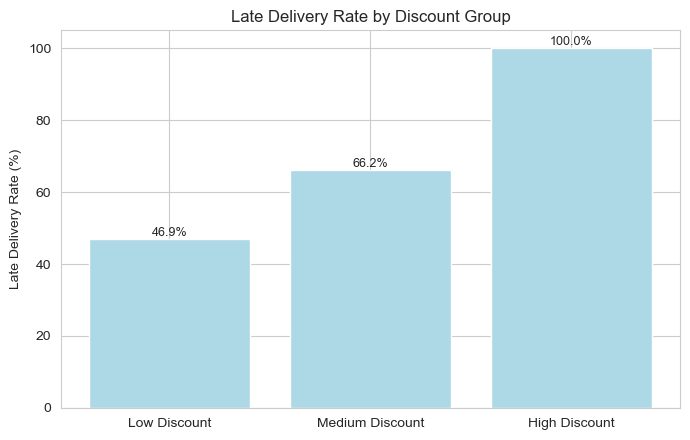

In [12]:
#Discount effect chart
fig, ax = plt.subplots(figsize=(7, 4.5))
annotated_barplot(ax, df_discount["discount_group"].astype(str), df_discount["late_pct"],
                   fmt="{:.1f}%", color="lightblue")
ax.set_ylabel("Late Delivery Rate (%)")
ax.set_title("Late Delivery Rate by Discount Group")
plt.tight_layout()
plt.show()

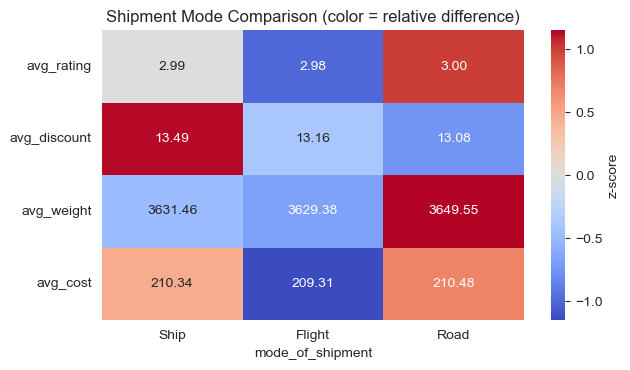

In [13]:
# Shipment mode comparison
q_mode = """
SELECT
    mode_of_shipment,
    COUNT(*) AS total_orders,
    ROUND(AVG(customer_rating), 2) AS avg_rating,
    ROUND(AVG(discount_offered), 2) AS avg_discount,
    ROUND(AVG(weight_in_gms), 2) AS avg_weight,
    ROUND(AVG(cost_of_the_product), 2) AS avg_cost
FROM shipping_data
GROUP BY mode_of_shipment;
"""
df_mode = pd.read_sql_query(q_mode, engine).set_index("mode_of_shipment")
metrics = df_mode[["avg_rating", "avg_discount", "avg_weight", "avg_cost"]]
z_scores = (metrics - metrics.mean()) / metrics.std()
fig, ax = plt.subplots(figsize=(6.5, 3.8))
sns.heatmap(z_scores.T, annot=metrics.T.values, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, cbar_kws={"label": "z-score"})
ax.set_title("Shipment Mode Comparison (color = relative difference)")
plt.tight_layout()
plt.show()

In [14]:
#Warehouse efficiency
q_efficiency = """
WITH warehouse_stats AS (
    SELECT
        warehouse_block,
        COUNT(*) AS total_orders,
        SUM(CASE WHEN reached_on_time_y_n = 0 THEN 1 ELSE 0 END) AS on_time
    FROM shipping_data
    GROUP BY warehouse_block
)
SELECT *,
       ROUND(on_time * 100.0 / total_orders, 2) AS on_time_percentage
FROM warehouse_stats
ORDER BY on_time_percentage DESC;
"""
df_efficiency = pd.read_sql_query(q_efficiency, engine)
df_efficiency["performance_rank"] = df_efficiency["on_time_percentage"].rank(ascending=False, method="min").astype(int)
df_efficiency

,warehouse_block,total_orders,on_time,on_time_percentage,performance_rank
0,A,1833,758,41.35,1
1,C,1833,739,40.32,2
2,D,1834,738,40.24,3
3,F,3666,1472,40.15,4
4,B,1833,729,39.77,5


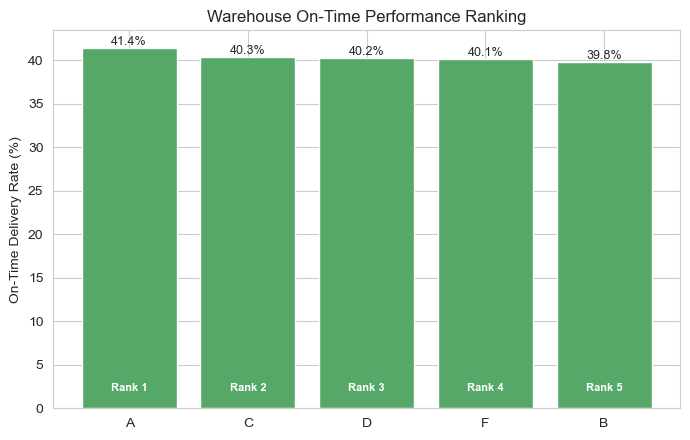

In [15]:
# Efficiency chart
fig, ax = plt.subplots(figsize=(7, 4.5))
annotated_barplot(ax, df_efficiency["warehouse_block"], df_efficiency["on_time_percentage"],
                   fmt="{:.1f}%", color="#55A868")
for i, rank in enumerate(df_efficiency["performance_rank"]):
    ax.annotate(f"Rank {rank}", (i, 2), ha="center", color="white", fontsize=8, fontweight="bold")
ax.set_ylabel("On-Time Delivery Rate (%)")
ax.set_title("Warehouse On-Time Performance Ranking")
plt.tight_layout()
plt.show()

In [16]:
#Top 10 revenue orders
q_revenue = """
SELECT
    id,
    warehouse_block,
    cost_of_the_product,
    discount_offered,
    (cost_of_the_product - discount_offered) AS estimated_revenue
FROM shipping_data
ORDER BY estimated_revenue DESC
LIMIT 10;
"""
df_revenue = pd.read_sql_query(q_revenue, engine)
df_revenue

,id,warehouse_block,cost_of_the_product,discount_offered,estimated_revenue
0,10195,D,310,1,309
1,8908,B,310,1,309
2,4820,F,310,1,309
3,4565,C,310,2,308
4,6889,D,309,1,308
5,9707,C,310,2,308
6,5532,F,308,1,307
7,9160,B,309,2,307
8,8881,D,308,1,307
9,5256,F,310,4,306


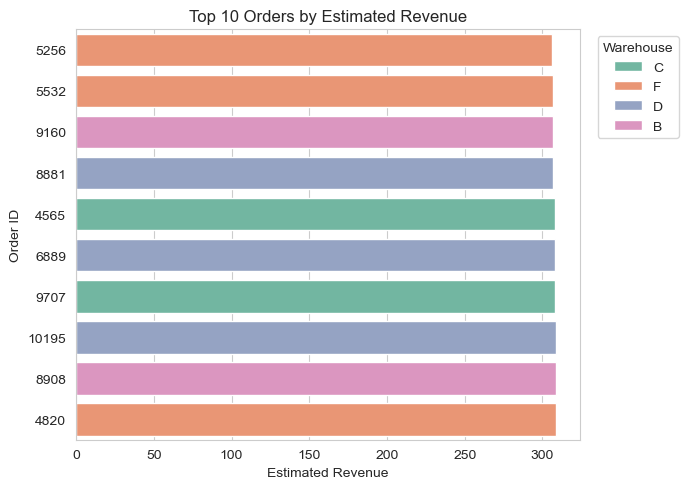

In [17]:
#Revenue chart
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=df_revenue, y="id", x="estimated_revenue", hue="warehouse_block",
            order=df_revenue.sort_values("estimated_revenue")["id"],
            dodge=False, palette="Set2", orient="h", ax=ax)
ax.set_title("Top 10 Orders by Estimated Revenue")
ax.set_xlabel("Estimated Revenue")
ax.set_ylabel("Order ID")
ax.legend(title="Warehouse", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [18]:
#Product importance vs cost/weight
q_importance = """
SELECT
    product_importance,
    ROUND(AVG(cost_of_the_product), 2) AS avg_cost,
    ROUND(AVG(weight_in_gms), 2) AS avg_weight
FROM shipping_data
GROUP BY product_importance;
"""
df_importance = pd.read_sql_query(q_importance, engine)
df_importance

,product_importance,avg_cost,avg_weight
0,medium,209.38,3712.05
1,high,203.87,4005.55
2,low,212.06,3497.49


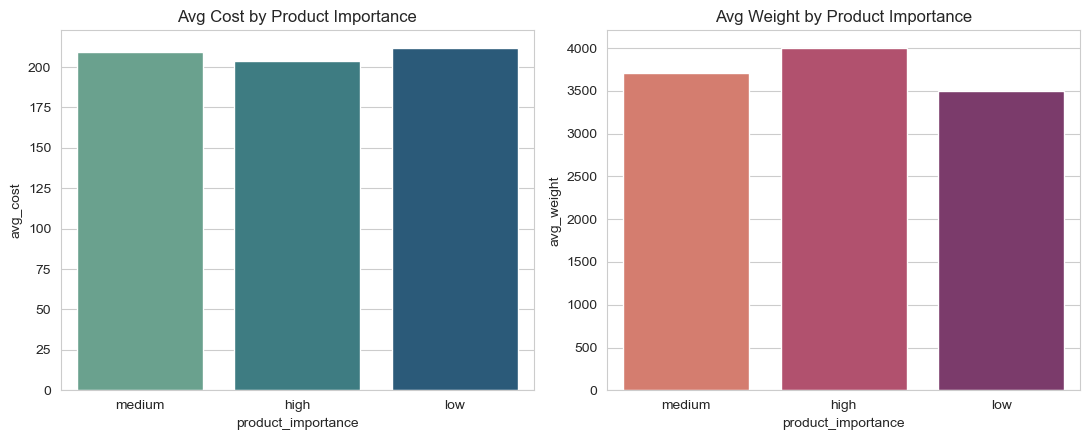

In [19]:
#Importance chart
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.barplot(data=df_importance, x="product_importance", y="avg_cost",
            hue="product_importance", legend=False, palette="crest", ax=axes[0])
axes[0].set_title("Avg Cost by Product Importance")
sns.barplot(data=df_importance, x="product_importance", y="avg_weight",
            hue="product_importance", legend=False, palette="flare", ax=axes[1])
axes[1].set_title("Avg Weight by Product Importance")

plt.tight_layout()
plt.show()

In [20]:
# Rating quartile (NTILE) merged back into full df
q_quartile = """
SELECT
    id,
    customer_rating,
    NTILE(4) OVER (ORDER BY customer_rating DESC) AS rating_quartile
FROM shipping_data;
"""
df_quartile = pd.read_sql_query(q_quartile, engine)
merged_quartile = df_quartile.merge(df[["id", "reached_on_time_y_n", "discount_offered"]], on="id")
quartile_summary = merged_quartile.groupby("rating_quartile").agg(
    orders=("id", "count"),
    rating_min=("customer_rating", "min"),
    rating_max=("customer_rating", "max"),
    late_pct=("reached_on_time_y_n", lambda s: round(s.mean() * 100, 2)),
    avg_discount=("discount_offered", "mean"),
).reset_index()
quartile_summary

,rating_quartile,orders,rating_min,rating_max,late_pct,avg_discount
0,1,2750,4,5,59.96,12.958909
1,2,2750,3,4,67.09,16.668727
2,3,2750,2,3,55.16,11.340727
3,4,2749,1,2,56.46,12.524191


In [21]:
 # share of total orders by warehouse block
q_share = """
SELECT
    warehouse_block,
    COUNT(*) AS total_orders,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS market_share
FROM shipping_data
GROUP BY warehouse_block;
"""
df_share = pd.read_sql_query(q_share, engine).sort_values("market_share", ascending=False)
df_share

,warehouse_block,total_orders,market_share
0,F,3666,33.33
1,D,1834,16.67
2,A,1833,16.67
3,C,1833,16.67
4,B,1833,16.67


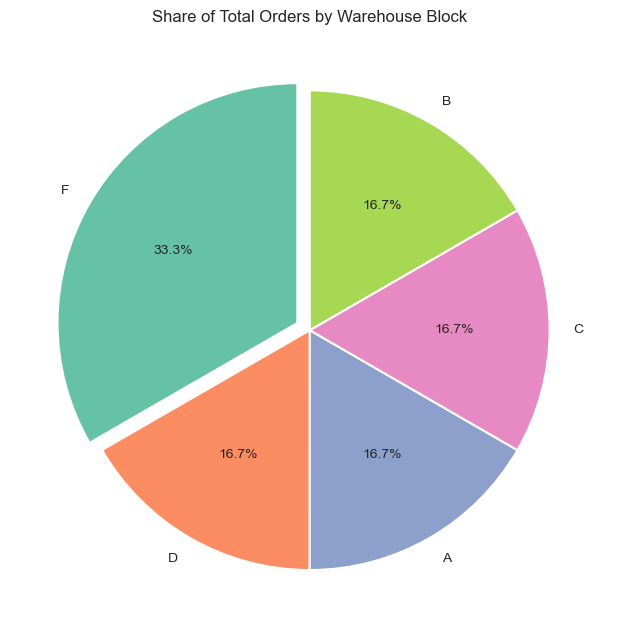

In [22]:
#share of total orders by warehouse block ,chart
explode = [0.06 if wb == df_share.iloc[0]["warehouse_block"] else 0 for wb in df_share["warehouse_block"]]
colors = sns.color_palette("Set2", n_colors=len(df_share))

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.pie(df_share["market_share"], labels=df_share["warehouse_block"], autopct="%1.1f%%",
       explode=explode, colors=colors, startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title("Share of Total Orders by Warehouse Block")
plt.tight_layout()
plt.show()

In [23]:
# late delivery rate vs product weight
df["weight_bin"] = pd.qcut(df["weight_in_gms"], q=8, duplicates="drop")
weight_trend = (
    df.groupby("weight_bin", observed=False)
      .agg(
          orders=("id", "count"),
          late_pct=("reached_on_time_y_n", lambda x: round(x.mean() * 100, 2)),
          avg_weight=("weight_in_gms", "mean")
      )
      .reset_index()
)
weight_trend["bin_label"] = (
    weight_trend["avg_weight"]
    .round()
    .astype(int)
    .astype(str)
    .add(" g")
)
weight_trend

,weight_bin,orders,late_pct,avg_weight,bin_label
0,"(1000.999, 1414.75]",1375,67.64,1203.743273,1204 g
1,"(1414.75, 1839.5]",1375,68.00,1632.224000,1632 g
2,"(1839.5, 2980.25]",1375,88.29,2281.002909,2281 g
3,"(2980.25, 4149.0]",1376,82.78,3696.689680,3697 g
4,"(4149.0, 4600.0]",1376,42.73,4375.425872,4375 g
5,"(4600.0, 5050.0]",1373,42.17,4823.197378,4823 g
6,"(5050.0, 5531.0]",1375,42.69,5291.431273,5291 g
7,"(5531.0, 7846.0]",1374,43.01,5771.118632,5771 g


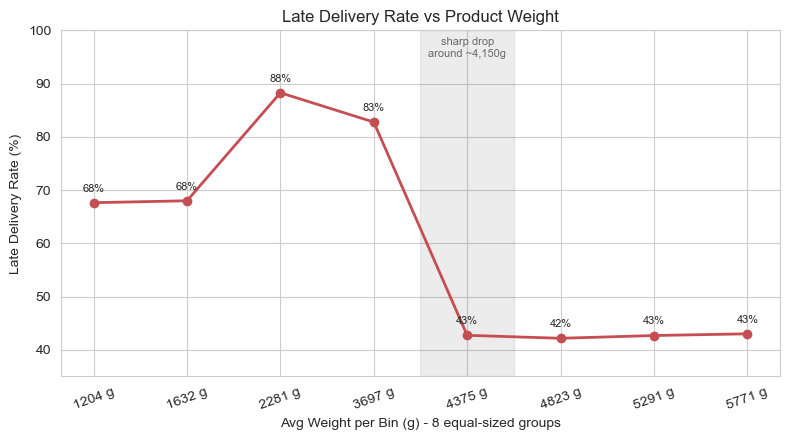

In [24]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(weight_trend["bin_label"], weight_trend["late_pct"], marker="o", linewidth=2, color="#C44E52")
for x, y in zip(weight_trend["bin_label"], weight_trend["late_pct"]):
    ax.annotate(f"{y:.0f}%", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
ax.axvspan(3.5, 4.5, color="grey", alpha=0.15)
ax.text(4, 95, "sharp drop\naround ~4,150g", ha="center", fontsize=8, color="dimgray")
ax.set_ylim(35, 100)
ax.set_xlabel("Avg Weight per Bin (g) - 8 equal-sized groups")
ax.set_ylabel("Late Delivery Rate (%)")
ax.set_title("Late Delivery Rate vs Product Weight")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

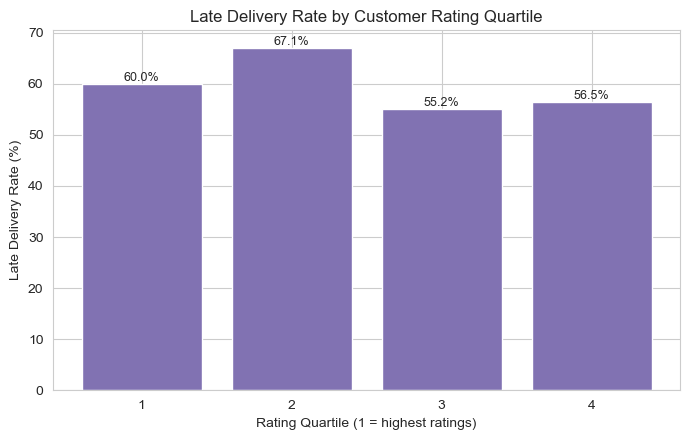

In [25]:
#Quartile chart
fig, ax = plt.subplots(figsize=(7, 4.5))
annotated_barplot(ax, quartile_summary["rating_quartile"].astype(str), quartile_summary["late_pct"],
                   fmt="{:.1f}%", color="#8172B2")
ax.set_xlabel("Rating Quartile (1 = highest ratings)")
ax.set_ylabel("Late Delivery Rate (%)")
ax.set_title("Late Delivery Rate by Customer Rating Quartile")
plt.tight_layout()
plt.show()

In [26]:
# Customer care calls vs delivery status
q_calls = """
SELECT
    CASE WHEN reached_on_time_y_n = 1 THEN 'Late' ELSE 'On Time' END AS delivery_status,
    ROUND(AVG(customer_care_calls), 2) AS avg_calls,
    ROUND(AVG(customer_rating), 2) AS avg_rating
FROM shipping_data
GROUP BY delivery_status;
"""
df_calls = pd.read_sql_query(q_calls, engine)
df_calls

,delivery_status,avg_calls,avg_rating
0,Late,3.99,3.01
1,On Time,4.15,2.97


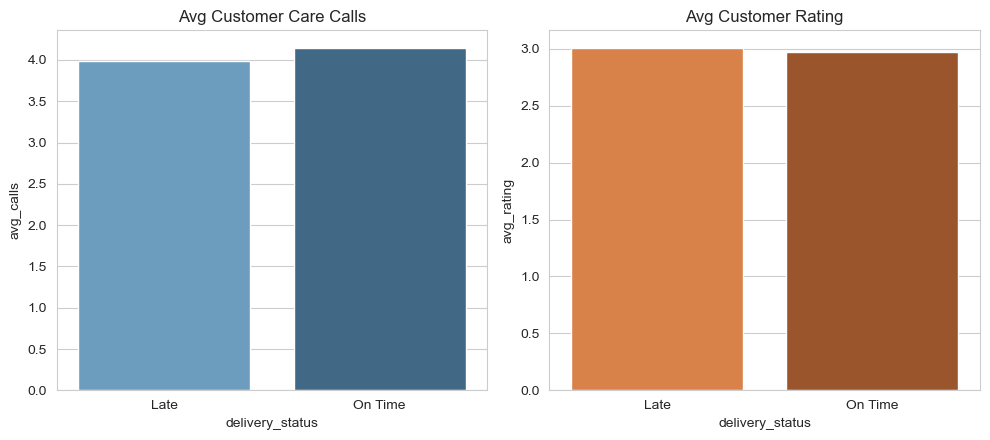

In [27]:
#Calls chart
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
sns.barplot(data=df_calls, x="delivery_status", y="avg_calls",
            hue="delivery_status", legend=False, palette="Blues_d", ax=axes[0])
axes[0].set_title("Avg Customer Care Calls")
sns.barplot(data=df_calls, x="delivery_status", y="avg_rating",
            hue="delivery_status", legend=False, palette="Oranges_d", ax=axes[1])
axes[1].set_title("Avg Customer Rating")

plt.tight_layout()
plt.show()

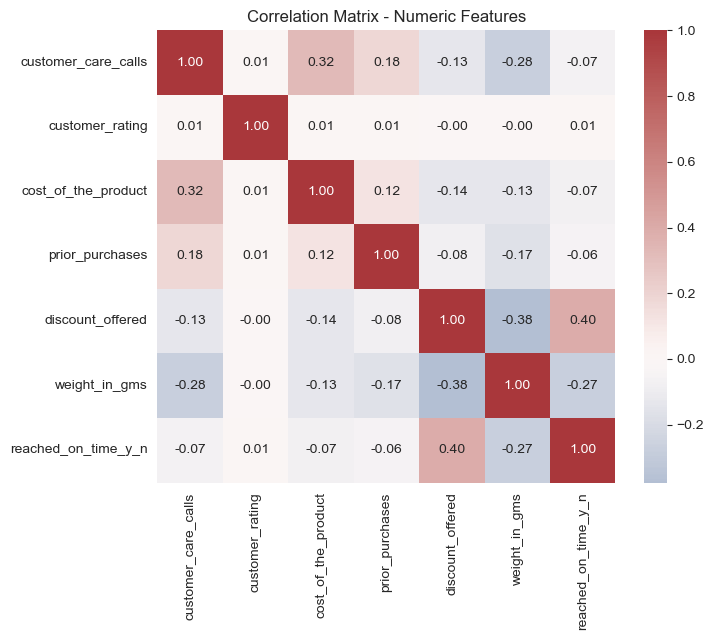

In [29]:
numeric_cols = [
    "customer_care_calls", "customer_rating", "cost_of_the_product",
    "prior_purchases", "discount_offered", "weight_in_gms", "reached_on_time_y_n",
]
corr_matrix = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(7.5, 6.5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Correlation Matrix - Numeric Features")
plt.tight_layout()
plt.show()